In [ ]:
# # !pip install --upgrade stable-baselines3 torch
# !pip install gymnasium[all] numpy matplotlib pandas seaborn opencv-python


^C


  Using cached pandas-2.3.1-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached ale_py-0.11.2-cp310-cp310-win_amd64.whl.metadata (9.2 kB)
  Using cached box2d_py-2.3.5-cp310-cp310-win_amd64.whl
  Using cached pygame-2.6.1-cp310-cp310-win_amd64.whl.metadata (13 kB)
  Using cached swig-4.3.1-py3-none-win_amd64.whl.metadata (3.5 kB)
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached array_api_compat-1.12.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.59.0-cp310-cp310-win_amd64.whl.metadata (110 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-1

In [20]:
# # !pip install panda_gym numpngw stable_baselines3
# !pip install notebook ipywidgets
# #
# !pip install jupyterlab
!pip install --force-reinstall tqdm rich



  You can safely remove it manually.



  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached rich-14.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached pygments-2.19.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached rich-14.1.0-py3-none-any.whl (243 kB)
Using cached pygments-2.19.2-py3-none-any.whl (1.2 MB)
Using cached markdown_it_py-3.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached colorama-0.4.6-py2.py3-none-any.whl (25 kB)

  Attempting uninstall: pygments

    Found existing installation: Pygments 2.19.2

   ---------------------------------------- 0/6 [pygments]
    Uninstalling Pygments-2.19.2:
   ---------------------------------------- 0/6 [pygments]
      Successfully uninstalled Pygments-2.19.2
  

In [23]:
# First, you need to install the required packages.
# The 'progress_bar' feature in stable-baselines3 depends on 'tqdm' and 'rich'.
# It's best to install them using the stable-baselines3[extra] option.
# If you are in an environment like a Jupyter Notebook, you might need to use `!pip`.
try:
    import tqdm
    import rich
except ImportError:
    print("tqdm or rich not found. Installing stable-baselines3 with extra dependencies...")
    # Using 'pip' to install the packages from within the script
    # This is a common practice in environments like notebooks or online runtimes.
    # We use stable-baselines3[extra] to get both tqdm and rich.
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "stable-baselines3[extra]"])
    print("Installation complete. Please re-run the script.")

import gymnasium as gym
import panda_gym
from stable_baselines3 import DDPG
from stable_baselines3.common.evaluation import evaluate_policy

# Initialize the environment.
# PandaReach-v3 is a dictionary observation space environment.
env = gym.make("PandaReach-v3")

# Initialize the DDPG model.
# Using MultiInputPolicy is correct for environments with dictionary observations.
# It's also good practice to set 'verbose=1' to see additional training info.
model = DDPG(policy="MultiInputPolicy", env=env, verbose=1)

# Start the training process with the progress bar enabled.
# The progress_bar=True argument will now work because the necessary
# dependencies (tqdm and rich) are installed.
print("Starting training with a progress bar...")
model.learn(total_timesteps=30_000, progress_bar=True)

# You can optionally save the trained model after training is complete
# model.save("ddpg_panda_reach")

print("Training finished.")



Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training with a progress bar...


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 37.8     |
|    ep_rew_mean     | -37.5    |
|    success_rate    | 0.25     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 114      |
|    time_elapsed    | 1        |
|    total_timesteps | 151      |
| train/             |          |
|    actor_loss      | 1.17     |
|    critic_loss     | 0.0162   |
|    learning_rate   | 0.001    |
|    n_updates       | 50       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 43.9     |
|    ep_rew_mean     | -43.8    |
|    success_rate    | 0.125    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 63       |
|    time_elapsed    | 5        |
|    total_timesteps | 351      |
| train/             |          |
|    actor_loss      | 2        |
|    critic_loss     | 0.0419   |
|    learning_

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30,000/30,000  [ 0:09:48 < 0:00:00 , 51 it/s ]

Training finished.


In [24]:
n_eval_ = 100 
mean_reward ,std = evaluate_policy(model,env,n_eval_episodes=n_eval_)
print(f"Mean reward {mean_reward} +/- {std}")

c:\Users\user\anaconda3\envs\sb3_env\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward -2.5 +/- 1.7


In [ ]:
from tqdm import tqdm
# A list to store the images (frames) for creating the video.

images = []
EPISODES = 10
print(f"\nStarting evaluation for {EPISODES} episodes...")

for episode in tqdm(range(EPISODES), desc="Evaluating Episodes"):
    # Reset the environment at the beginning of each episode.
    # Gymnasium reset() now returns a tuple: (observation, info).
    obs, _ = env.reset()
    
    # Render the initial state and append it to the images list.
    images.append(env.render())
    
    total_reward = 0
    done = False
    
    # Loop until the episode is terminated or truncated.
    while not done:
        # Predict the action using the model.
        # model.predict returns a tuple (action, hidden_state).
        # We only need the action for the step.
        action, _ = model.predict(obs, deterministic=True)
        
        # Take a step in the environment with the predicted action.
        # env.step() returns a tuple (observation, reward, terminated, truncated, info).
        obs, reward, terminated, truncated, _ = env.step(action)
        
        # Accumulate the reward.
        total_reward += reward
        
        # The episode is done if it's terminated or truncated.
        done = terminated or truncated
        
        # Render the new state and append it to the images list.
        images.append(env.render())
        
    print(f"Episode {episode+1} finished with total reward: {total_reward:.2f}")

# Close the environment after the evaluation is complete.



Starting evaluation for 10 episodes...


Episode 1 finished with total reward: -3.00


Episode 2 finished with total reward: 0.00


Episode 3 finished with total reward: -2.00


Episode 4 finished with total reward: -1.00


...

Episode 7 finished with total reward: -2.00


Episode 8 finished with total reward: -1.00


Episode 9 finished with total reward: -2.00




Evaluating Episodes: 100%|██████████| 10/10 [00:09<00:00,  1.07it/s]

Episode 10 finished with total reward: -1.00


In [32]:
reward_history_before = []
reward_history_after = []  
episodes = 32


for episode in range(episodes):
    obs, info = env.reset()
    done = False
    total_reward_before = 0
    while not done:
        action = env.action_space.sample() 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward_before += reward
        if terminated or truncated:
            done = True
    reward_history_before.append(total_reward_before)
    print(f"Episode: {episode + 1}, Total Reward Before: {total_reward_before}")

print(f"Average Reward Before: {sum(reward_history_before) / episodes}")

Episode: 1, Total Reward Before: -50.0
Episode: 2, Total Reward Before: -50.0
Episode: 3, Total Reward Before: -50.0
Episode: 4, Total Reward Before: -50.0
Episode: 5, Total Reward Before: -50.0
Episode: 6, Total Reward Before: -6.0
Episode: 7, Total Reward Before: -1.0
Episode: 8, Total Reward Before: -50.0
Episode: 9, Total Reward Before: -50.0
Episode: 10, Total Reward Before: -50.0
Episode: 11, Total Reward Before: -10.0
Episode: 12, Total Reward Before: -50.0
Episode: 13, Total Reward Before: -50.0
Episode: 14, Total Reward Before: -45.0
Episode: 15, Total Reward Before: -50.0
Episode: 16, Total Reward Before: -50.0
Episode: 17, Total Reward Before: -50.0
Episode: 18, Total Reward Before: -17.0
Episode: 19, Total Reward Before: -4.0
Episode: 20, Total Reward Before: -50.0
Episode: 21, Total Reward Before: -50.0
Episode: 22, Total Reward Before: -50.0
Episode: 23, Total Reward Before: -7.0
Episode: 24, Total Reward Before: -50.0
Episode: 25, Total Reward Before: -50.0
Episode: 26, 

In [33]:

for episode in range(episodes):
    obs, info = env.reset()
    done = False
    total_reward_after = 0
    while not done:
        action,_ = model.predict(obs,deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward_after += reward
        if terminated or truncated:
            done = True
    reward_history_after.append(total_reward_after)
    print(f"Episode: {episode + 1}, Total Reward after: {total_reward_after}")

print(f"Average Reward after: {sum(reward_history_after) / episodes}")

Episode: 1, Total Reward after: -8.0
Episode: 2, Total Reward after: -2.0
Episode: 3, Total Reward after: -3.0
Episode: 4, Total Reward after: -4.0
Episode: 5, Total Reward after: -2.0
Episode: 6, Total Reward after: -2.0
Episode: 7, Total Reward after: -2.0
Episode: 8, Total Reward after: -3.0
Episode: 9, Total Reward after: -3.0
Episode: 10, Total Reward after: -1.0
Episode: 11, Total Reward after: -7.0
Episode: 12, Total Reward after: -2.0
Episode: 13, Total Reward after: -2.0
Episode: 14, Total Reward after: -6.0
Episode: 15, Total Reward after: -2.0
Episode: 16, Total Reward after: -6.0
Episode: 17, Total Reward after: -2.0
Episode: 18, Total Reward after: -6.0
Episode: 19, Total Reward after: -1.0
Episode: 20, Total Reward after: -2.0
Episode: 21, Total Reward after: -1.0
Episode: 22, Total Reward after: -1.0
Episode: 23, Total Reward after: -1.0
Episode: 24, Total Reward after: -3.0
Episode: 25, Total Reward after: -1.0
Episode: 26, Total Reward after: -1.0
Episode: 27, Total Re

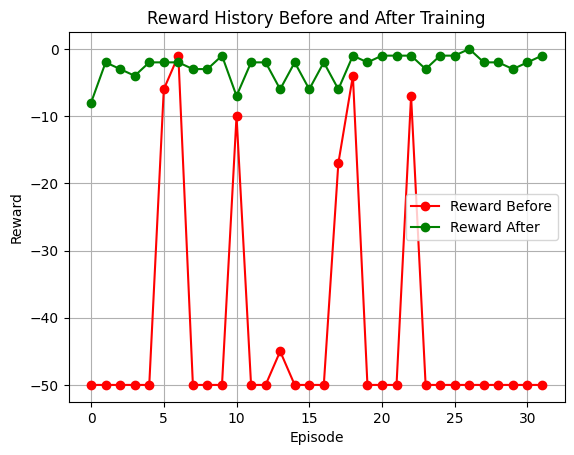

In [34]:
import matplotlib.pyplot as plt

plt.plot(reward_history_before, label='Reward Before', color='red', linestyle='-',marker='o')
plt.plot(reward_history_after, label='Reward After', color='green', linestyle='-',marker='o')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward History Before and After Training')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
from numpngw import write_apng 
images = [] 
total_reward = 0 

obs ,info = env.reset()
images.append(env.render())
done = False 
while not done:
  action,_ = model.predict(obs,deterministic=True)
  obs,reward,terminated,truncated,info = env.step(action)
  images.append(env.render())

  total_reward += reward 
  if terminated or truncated:
    break 
print(f"Total Reward: {total_reward}")
write_apng('output.png',images,delay=500)

Total Reward: -2.0
